In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [12]:
x = np.linspace(0.1, 2 * np.pi, 100)
a_true, b_true = 5.0, 0.5
y_clean = a_true * np.exp(-b_true * x)

sigma = np.linspace(2, 0.2, 100)
y_scatter = np.random.normal(y_clean, sigma)

In [13]:
def model1(x, a, b):
    return a * np.exp(-b * x)

def model2(x, a, b):
    return a / (x**b)

In [22]:
best_values1, uncertainty1 = curve_fit(model1, x, y_scatter)
best_values2, uncertainty2 = curve_fit(model2, x, y_scatter)

a_fit1 = best_values1[0]
b_fit1 = best_values1[1]

a_fit2 = best_values2[0]
b_fit2 = best_values2[1]

print(f"the best fit for model 1 is a = {a_fit1} and b = {b_fit1}")
print(f"The best fit for model 2 is a = {a_fit2} and b = {b_fit2}")

the best fit for model 1 is a = 6.074006588559275 and b = 0.5088958793985199
The best fit for model 2 is a = 2.528898312980062 and b = 0.46255439689397027


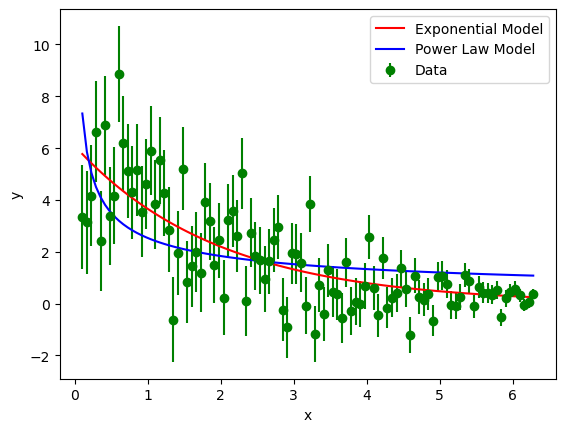

In [23]:
plt.errorbar(x, y_scatter, yerr=sigma, fmt='o', color='green', label='Data')

y_model1 = model1(x, a_fit1, b_fit1)
plt.plot(x, y_model1, color='red', label='Exponential Model')

y_model2 = model2(x, a_fit2, b_fit2)
plt.plot(x, y_model2, color='blue', label='Power Law Model')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.savefig('model_comparison.pdf')
plt.show()